In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler

In [2]:
from google.colab import files

uploaded = files.upload()

Saving cleaned_data.csv to cleaned_data.csv


In [3]:
df = pd.read_csv(
    "cleaned_data.csv"
)

In [4]:
df.head()
df.shape

(7500, 17)

In [5]:
df['sleep_deficit'] = (
    8
    -
    df['sleep_hours']
)

In [6]:
df['sleep_deficit'] = (
    df['sleep_deficit']
    .clip(lower=0)
)

In [7]:
df[
    'weekend_overuse'
] = (
    df['weekend_screen_time']
    -
    df['daily_screen_time_hours']
)

In [8]:
df[
    'weekend_overuse'
] = (
    df['weekend_overuse']
    .clip(lower=0)
)

In [9]:
dei_features = [

    'daily_screen_time_hours',

    'social_media_hours',

    'gaming_hours',

    'sleep_deficit',

    'weekend_overuse'

]

In [10]:
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(
    df[dei_features]
)

In [11]:
scaled_df = pd.DataFrame(
    scaled_data,
    columns=dei_features
)

In [12]:
df['DEI'] = (

    0.35 *
    scaled_df[
        'daily_screen_time_hours'
    ]

    +

    0.25 *
    scaled_df[
        'social_media_hours'
    ]

    +

    0.10 *
    scaled_df[
        'gaming_hours'
    ]

    +

    0.20 *
    scaled_df[
        'sleep_deficit'
    ]

    +

    0.10 *
    scaled_df[
        'weekend_overuse'
    ]

)

In [13]:
df['DEI'] = (
    df['DEI']
    * 100
)

In [14]:
df[
    [
        'daily_screen_time_hours',
        'sleep_hours',
        'DEI'
    ]
].head()

,daily_screen_time_hours,sleep_hours,DEI
0,3.23,7.55,13.434509
1,5.09,7.66,35.196089
2,6.06,4.92,51.464091
3,7.83,8.23,52.636515
4,9.96,6.21,78.841602


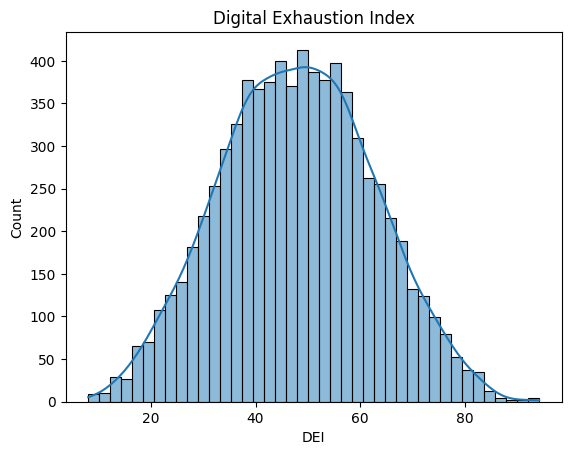

In [15]:
sns.histplot(
    data=df,
    x='DEI',
    kde=True
)

plt.title(
    "Digital Exhaustion Index"
)

plt.show()

In [16]:
df['DEI'].describe()

,DEI
count,7500.000000
mean,47.940261
std,14.612247
min,7.963081
25%,37.527677
50%,47.980938
75%,58.217868
max,94.281724


In [22]:
conditions = [

    df['DEI'] < 33,

    (df['DEI'] >= 33)
    &
    (df['DEI'] < 66),

    df['DEI'] >= 66

]

categories = [

    'Low',

    'Moderate',

    'High'

]

['age', 'gender', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time', 'stress_level', 'academic_work_impact', 'addiction_level', 'addicted_label', 'weekend_usage_difference', 'sleep_deficit', 'notification_intensity', 'weekend_overuse', 'DEI']


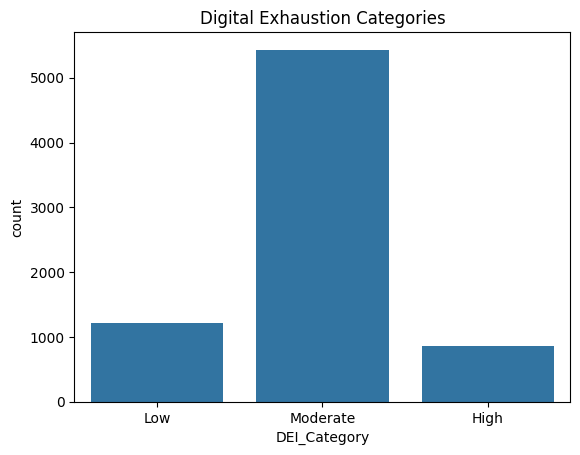

In [24]:
# Check columns
print(df.columns.tolist())

# Create DEI_Category if it doesn't exist
if 'DEI_Category' not in df.columns:

    df['DEI_Category'] = pd.cut(
        df['DEI'],
        bins=[0, 33, 66, 100],
        labels=['Low', 'Moderate', 'High'],
        include_lowest=True
    )

# Plot category distribution
sns.countplot(
    data=df,
    x='DEI_Category'
)

plt.title("Digital Exhaustion Categories")
plt.show()

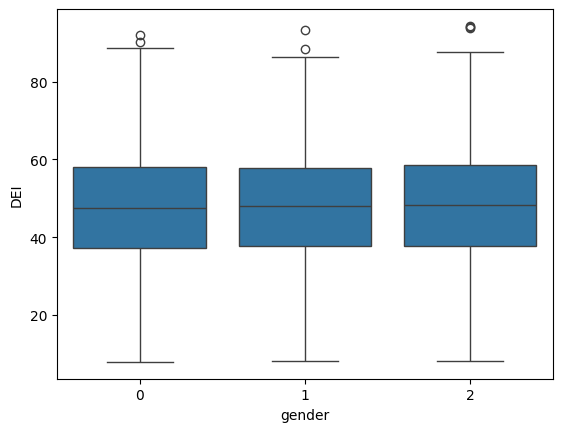

In [26]:
#Average DEI by Gender
sns.boxplot(
    data=df,
    x='gender',
    y='DEI'
)

plt.show()

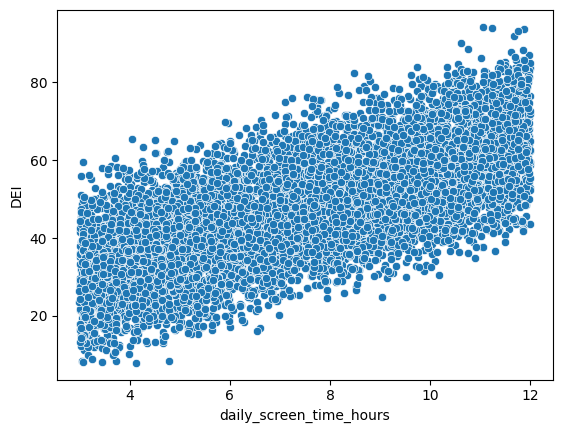

In [27]:
#Screen Time vs DEI
sns.scatterplot(
    data=df,
    x='daily_screen_time_hours',
    y='DEI'
)

plt.show()

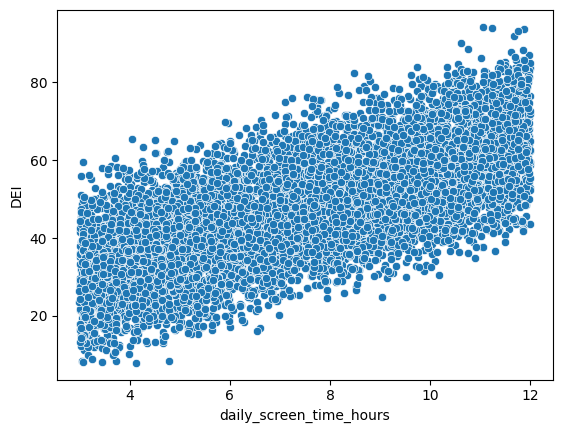

In [28]:
#Screen Time vs DEI
sns.scatterplot(
    data=df,
    x='daily_screen_time_hours',
    y='DEI'
)

plt.show()

Research Findings

1. Increased screen time strongly contributes to exhaustion.

2. Users sleeping below 6 hours
have significantly higher DEI.

3. Heavy social media users
show elevated exhaustion scores.

4. Weekend overuse increases
overall exhaustion.

In [29]:
df.to_csv(
    "DEI_dataset.csv",
    index=False
)

In [30]:
from google.colab import files

files.download(
    "DEI_dataset.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>